# Spatial Analysis of ZüriWieNeu Reports

In [1]:
import geopandas as gpd
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc


DATA_PROCESSED = Path("../data/processed")
OUTPUTS = Path("../outputs")

In [2]:
reports_quartiere_clean = gpd.read_file(
    DATA_PROCESSED / "reports_quartiere_clean.gpkg"
)

quartiere_join_clean = gpd.read_file(
    DATA_PROCESSED / "quartiere_join.gpkg"
)

## Reports per Quartier

In [20]:
reports_per_quartier = (
    reports_quartiere_clean
    .groupby("name")
    .size()
    .reset_index(name="report_count")
)
reports_per_quartier.head()

,name,report_count
0,Affoltern,2437
1,Albisrieden,2059
2,Alt-Wiedikon,2532
3,Altstetten,4136
4,City,1754


In [21]:
reports_per_quartier_gdf = reports_per_quartier.merge(
    quartiere_join_clean,
    on = "name",
    how="left"
)

reports_per_quartier_gdf.head()

,name,report_count,kuerzel,geometry
0,Affoltern,2437,111,"POLYGON ((8.48438 47.42904, 8.48443 47.42899, ..."
1,Albisrieden,2059,91,"POLYGON ((8.46419 47.36838, 8.4642 47.36783, 8..."
2,Alt-Wiedikon,2532,31,"POLYGON ((8.50583 47.36922, 8.50583 47.36922, ..."
3,Altstetten,4136,92,"POLYGON ((8.44802 47.38025, 8.44848 47.37966, ..."
4,City,1754,14,"POLYGON ((8.52922 47.3692, 8.52943 47.36903, 8..."


In [5]:
reports_per_quartier_gdf = gpd.GeoDataFrame(
    reports_per_quartier_gdf,
    geometry="geometry",
    crs=quartiere_join_clean.crs
)

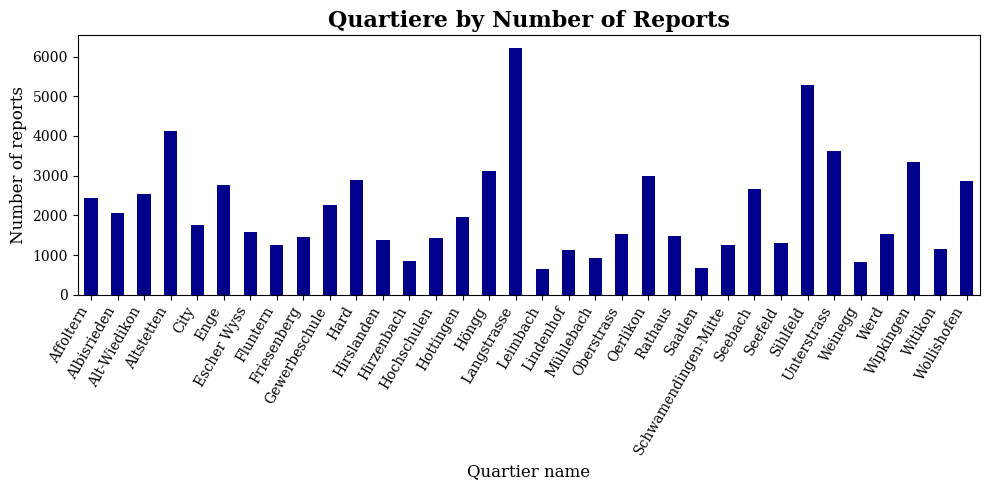

In [6]:
reports_per_quartier_gdf.plot(
    kind="bar",
    color="darkblue",
    figsize=(10,5),
    x="name",
    y="report_count",
    legend=False
)

plt.xlabel("Quartier name", fontsize=12, fontfamily="serif")
plt.ylabel("Number of reports", fontsize=12, fontfamily="serif")
plt.title("Quartiere by Number of Reports", fontsize=16, fontweight="bold", fontfamily="serif")
plt.xticks(rotation=60, ha="right", fontfamily="serif")
plt.yticks(fontfamily="serif")
plt.tight_layout()
plt.show()

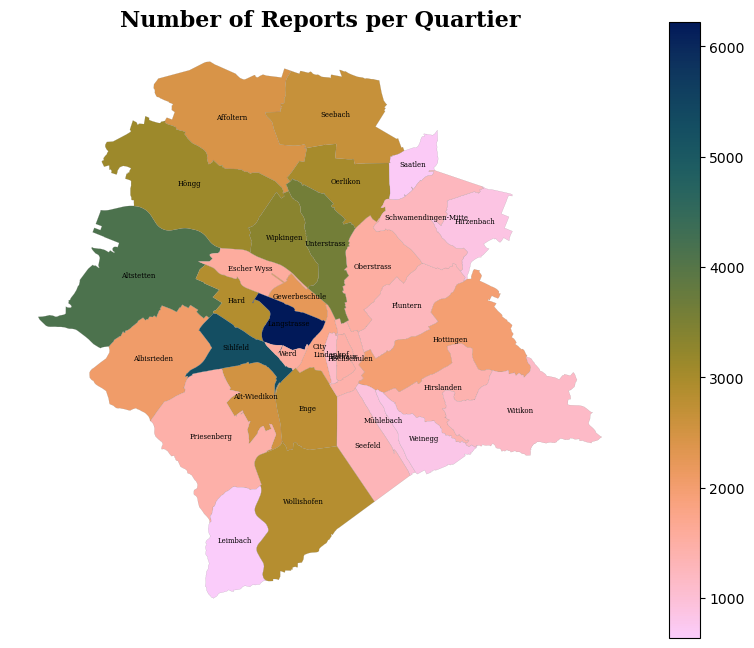

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the choropleth map using the population column
reports_per_quartier_gdf.plot(
    ax=ax, 
    column="report_count",
    cmap=cmc.batlow_r,
    legend=True,
    edgecolor="grey",
    linewidth=0.1
)

for idx, row in reports_per_quartier_gdf.iterrows():
    ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["name"],
        fontsize=5,
        ha="center",
        fontfamily="serif"
    )

ax.set_title("Number of Reports per Quartier", fontsize=16, fontweight="bold", fontfamily="serif")
ax.axis("off")
plt.savefig(
    OUTPUTS / "reports_per_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Most Common Report Categories

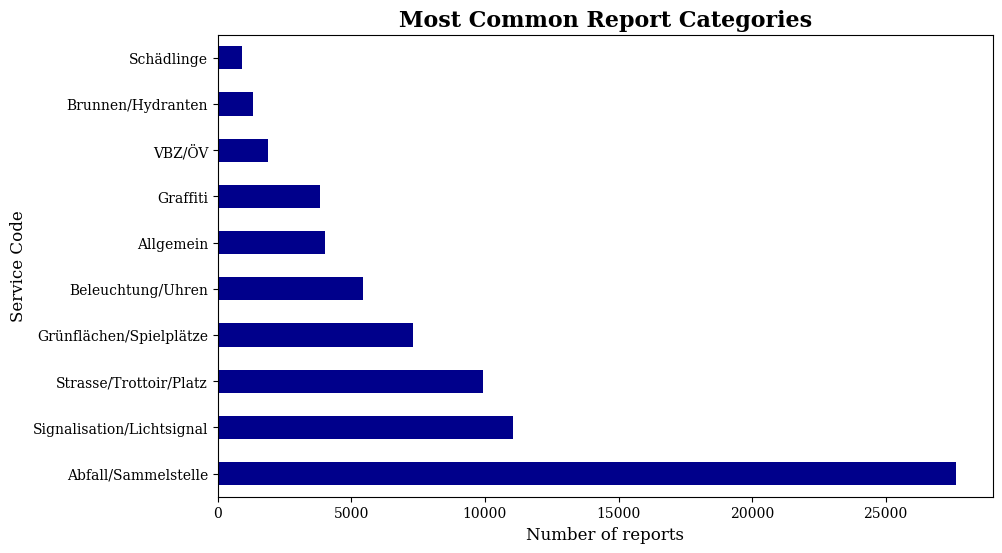

In [8]:
reports_quartiere_clean["service_code"].value_counts().plot(
    kind="barh",
    figsize=(10,6),
    color="darkblue"
)

plt.xlabel("Number of reports", fontsize=12, fontfamily="serif")
plt.ylabel("Service Code", fontsize=12, fontfamily="serif")
plt.title("Most Common Report Categories", fontsize=16, fontweight="bold", fontfamily="serif")
plt.xticks(fontfamily="serif")
plt.yticks(fontfamily="serif")
plt.savefig(
    OUTPUTS / "most_common_report_categories_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Most Common Report Categories per Quartier

In [9]:
category_counts = (
    reports_quartiere_clean
        .groupby(
            ["name", "service_code"]
        )
        .size()
        .reset_index(name="count")
)
category_counts.head()

,name,service_code,count
0,Affoltern,Abfall/Sammelstelle,790
1,Affoltern,Allgemein,109
2,Affoltern,Beleuchtung/Uhren,247
3,Affoltern,Brunnen/Hydranten,30
4,Affoltern,Graffiti,133


In [10]:
top_categories = (
    category_counts
    .sort_values(
        ["name", "count"],
        ascending=[True, False]
    )
    .groupby("name")
    .head(3)
)

In [11]:
category_plot = top_categories.pivot(
    index="name",
    columns="service_code",
    values="count"
).fillna(0)

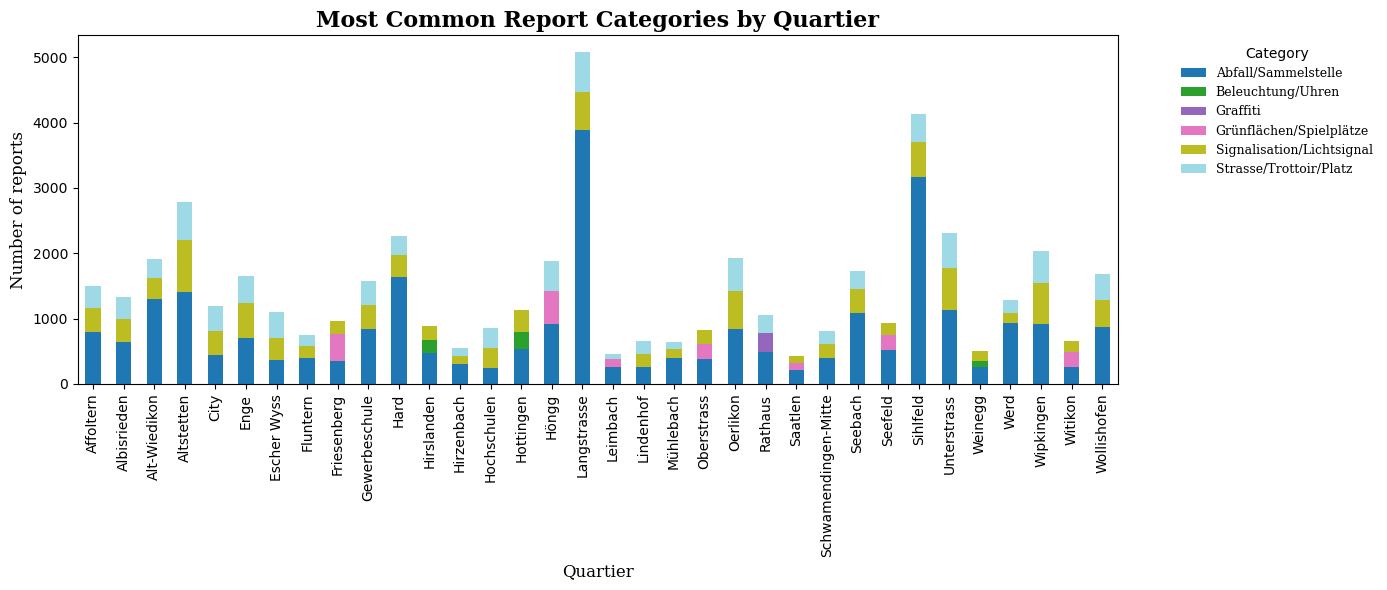

In [12]:
fig, ax = plt.subplots (figsize=(16,7))

category_plot.plot(
    kind = "bar",
    stacked = True,
    figsize= (14,6),
    cmap="tab20",
    ax=ax
)

ax.set_xlabel("Quartier", fontsize=12, fontfamily="serif")
ax.set_ylabel("Number of reports", fontsize=12, fontfamily="serif")
ax.set_title("Most Common Report Categories by Quartier", fontsize=16, fontweight="bold", fontfamily="serif")

ax.legend(
    title = "Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    prop={"family": "serif", "size": 9}
)

plt.tight_layout()
plt.savefig(
    OUTPUTS / "common_report_categories_by_quartier_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [13]:
main_category = (
    category_counts
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("name")
    .first()
    .reset_index()
)

In [14]:
quartiere_main = quartiere_join_clean.merge(
    main_category,
    left_on="name",
    right_on="name"
)

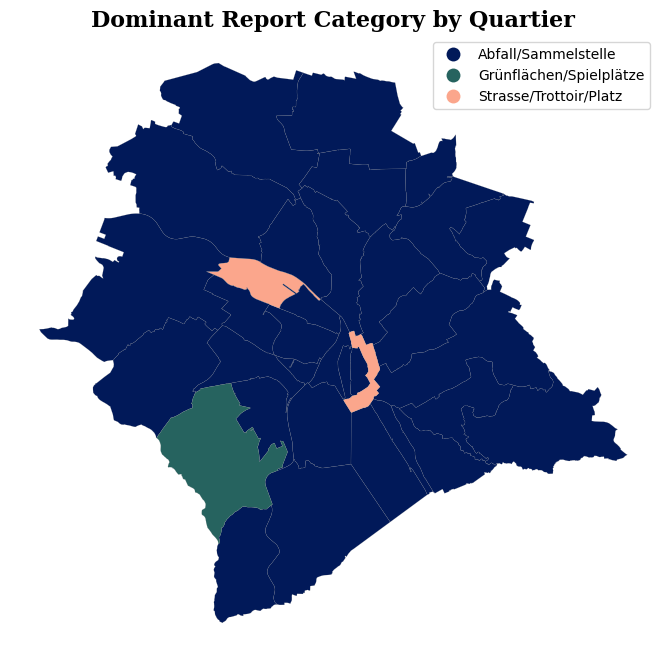

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the choropleth map using the population column
quartiere_main.plot(
    ax=ax, 
    column="service_code",
    cmap=cmc.batlowS,
    legend=True,
    edgecolor="grey",
    linewidth=0.1
)

ax.set_title("Dominant Report Category by Quartier", fontsize=16, fontweight="bold", fontfamily="serif")
ax.axis("off")
plt.savefig(
    OUTPUTS / "dominant_report_category_by_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Reports over Time

In [17]:
reports_quartiere_clean["month"] = (
    reports_quartiere_clean["requested_datetime"]
    .dt.to_period("M")
)

In [18]:
monthly_reports = (
    reports_quartiere_clean
    .set_index("requested_datetime")
    .groupby("month")
    .size()
)

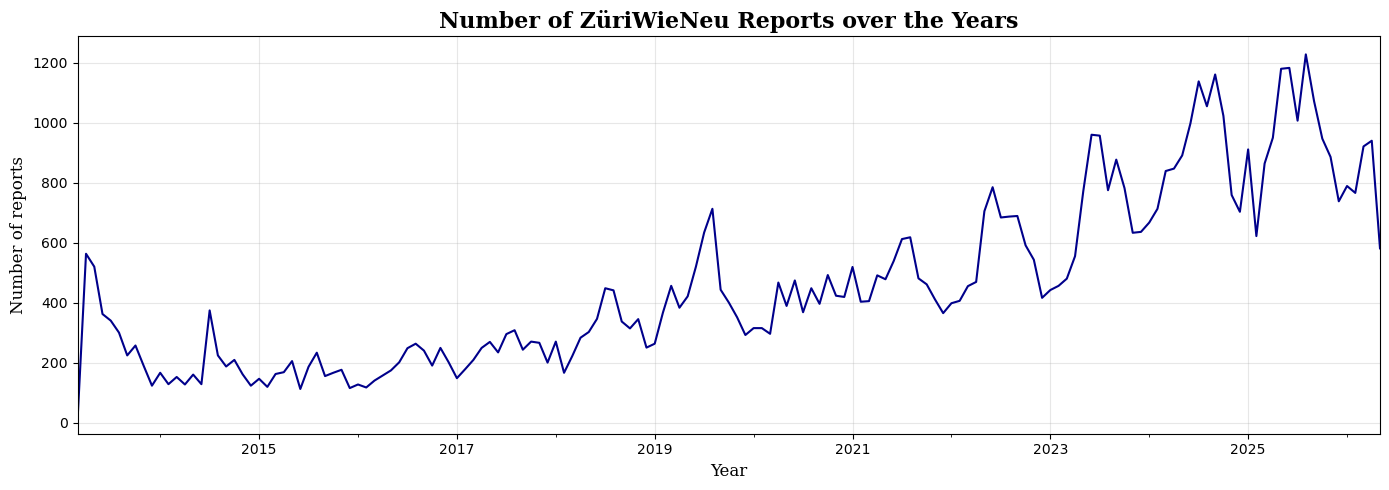

In [19]:
monthly_reports.plot(
    figsize=(14,5),
    color = "darkblue"
)

plt.xlabel("Year", fontsize=12, fontfamily="serif")
plt.ylabel("Number of reports", fontsize=12, fontfamily="serif")
plt.title("Number of ZüriWieNeu Reports over the Years", fontsize=16, fontweight="bold", fontfamily="serif")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUTPUTS / "number_of_reports_over_time_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()